# Exploratory Data Analysis

To begin, let's take a look at the training dataset and the terminology. 
- `koi` stands for Kepler Objects of Interest, essentially exoplanet candidates.
- `koi_disposition` classifies KOIs as either a CANDIDATE, FALSE POSITIVE, or CONFIRMED

We want to clean through the provided dataset and purely focus on KOIs that are confirmed exoplanets.


In [8]:
import pandas as pd

# Store the .csv file as a 'DataFrame' data type (provided by the pandas library)
df = pd.read_csv('../data/cumulative.csv')

# Count all of the values found in the 'koi_disposition' column
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

We can clearly see the three types of KOI dispositions:
- `FALSE POSITIVE`
- `CONFIRMED`
- `CANDIDATE`

What we know is true is either the `FALSE POSITIVE` or the `CONFIRMED` disposition and this is what we need to train our scikit-learn model. Let's drop the `CANDIDATE` column now and convert this to be a binary label column for easier use.

In [10]:
# Remove the 'CANDIDATE' column via filtering
df = df[df['koi_disposition'] != 'CANDIDATE']

# Creates a new column if it did not exist before, where if the 'koi_disposition' is 'CONFIRMED', then it's a 1, otherwise its a 0
df['label'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)

# Testing
print(df['label'].value_counts())

label
0    5023
1    2293
Name: count, dtype: int64


Now that we've filtered the DataFrame for either `CONFIRMED` or `FALSE POSITIVES`, we will also need to check for any rows with missing values. This will be important later

In [20]:

# Find values within the columns that are null and shows the first 20 columns
# Raw values:
print(df.isnull().sum().sort_values(ascending=False).head(20))

koi_teq_err2         7316
koi_teq_err1         7316
kepler_name          5022
koi_score            1059
koi_steff_err2        412
koi_srad_err1         397
koi_slogg_err2        397
koi_srad_err2         397
koi_steff_err1        397
koi_slogg_err1        397
koi_depth_err2        377
koi_time0bk_err1      377
koi_time0bk_err2      377
koi_period_err1       377
koi_impact_err1       377
koi_duration_err1     377
koi_impact_err2       377
koi_depth_err1        377
koi_period_err2       377
koi_duration_err2     377
dtype: int64


In [24]:
# Percentage:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(20)

koi_teq_err2         100.000000
koi_teq_err1         100.000000
kepler_name           68.644068
koi_score             14.475123
koi_steff_err2         5.631493
koi_srad_err1          5.426463
koi_slogg_err2         5.426463
koi_srad_err2          5.426463
koi_steff_err1         5.426463
koi_slogg_err1         5.426463
koi_depth_err2         5.153089
koi_time0bk_err1       5.153089
koi_time0bk_err2       5.153089
koi_period_err1        5.153089
koi_impact_err1        5.153089
koi_duration_err1      5.153089
koi_impact_err2        5.153089
koi_depth_err1         5.153089
koi_period_err2        5.153089
koi_duration_err2      5.153089
dtype: float64

Let's also take a statistical overview of the dataset's key features too.

In [25]:
key_features = ['koi_period', 'koi_depth', 'koi_duration',
                'koi_prad', 'koi_teq', 'koi_impact',
                'koi_steff', 'koi_slogg', 'koi_srad']

df[key_features].describe()

,koi_period,koi_depth,koi_duration,koi_prad,koi_teq,koi_impact,koi_steff,koi_slogg,koi_srad
count,7316.000000,7.016000e+03,7316.000000,7016.000000,7016.000000,7016.000000,7016.000000,7016.000000,7016.000000
mean,58.816738,3.062011e+04,5.865646,129.973917,1148.595639,0.796773,5727.706813,4.303516,1.779288
std,121.082398,9.287398e+04,6.965178,3519.623953,898.326612,3.668625,825.221536,0.444626,6.203126
min,0.241843,8.000000e-01,0.104600,0.080000,92.000000,0.000000,2661.000000,0.047000,0.116000
25%,2.237412,1.845500e+02,2.527525,1.520000,559.000000,0.224000,5320.000000,4.206750,0.829000
50%,8.507657,5.074500e+02,3.904750,2.680000,928.000000,0.576000,5779.500000,4.438000,1.000000
75%,36.184630,2.775100e+03,6.432175,25.450000,1496.250000,0.916250,6126.000000,4.543000,1.367000
max,1071.232624,1.541400e+06,138.540000,200346.000000,14667.000000,100.806000,15896.000000,5.283000,229.908000


Let's visualize this to get a better sense of what these numbers mean

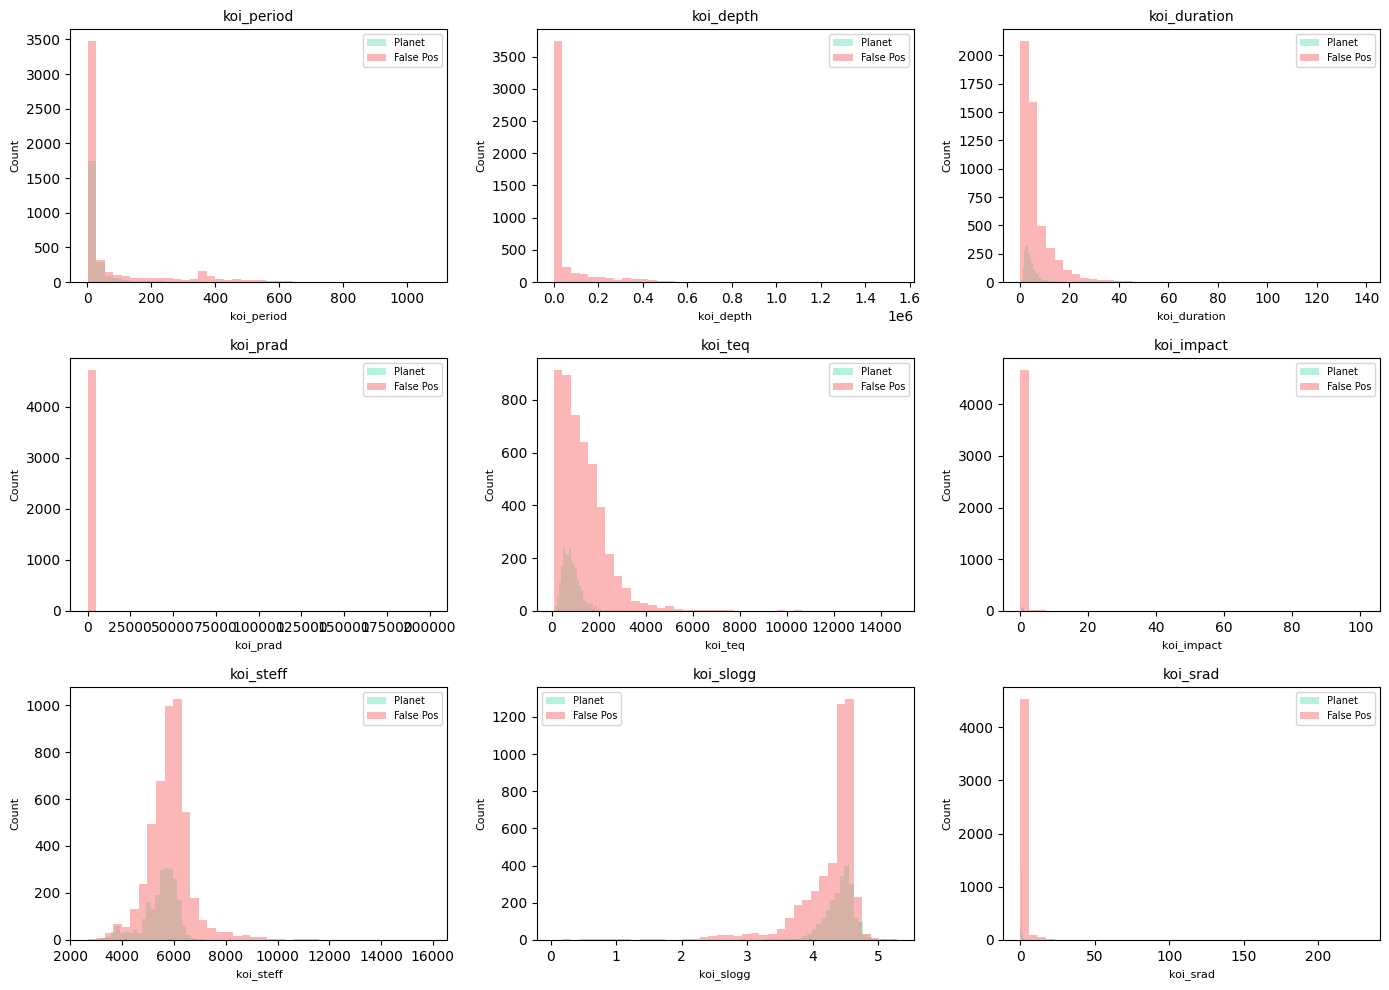

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_features):
    for label, color in [(1, '#6ee7b7'), (0, '#f87171')]:
        subset = df[df['label'] == label]
        ax.hist(subset[col].dropna(), bins=40, alpha=0.5,
                color=color, label='Planet' if label else 'False Pos')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

Right now, we can take note of how `koi_period`, `koi_depth`, `koi_prad`, `koi_duration`, and `koi_srad` are heavily skewed to the left. The histograms are just generally hard to interpret what's going on because of the outliers; outliers compress the data such that the data is hard to view and interpret. Outliers will also mess up our classifier model too, so they will need to be dealt with. To do this, we can apply a logarithmic function onto the data to handle the skewed data. Logs will compress outliers while spreading out the actual information we want. 

This will be the same function as before but we will include `np.log1p()`, meaning `log(1 + n)` where the 1 is to handle edge cases if `n` is zero. Let's see how it looks now.

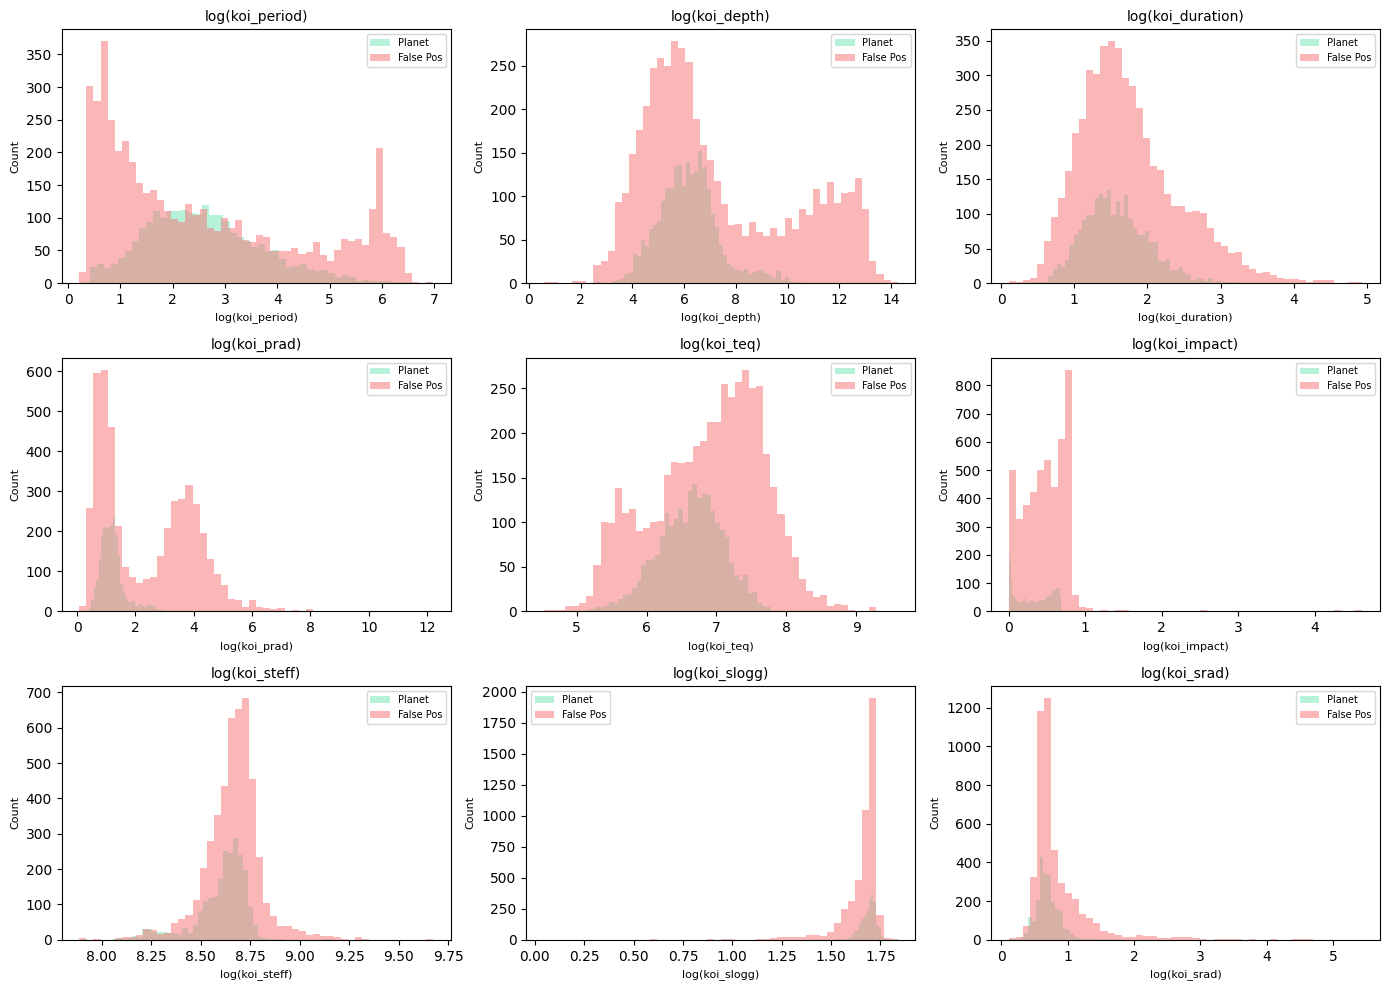

In [36]:
import numpy as np

log_features = ['koi_period', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_srad', 'koi_impact', 'koi_teq', 'koi_slogg', 'koi_steff']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_features):
    for label, color, name in [(1, '#6ee7b7', 'Planet'), (0, '#f87171', 'False Pos')]:
        subset = df[df['label'] == label][col].dropna()
        if col in log_features:
            subset = np.log1p(subset)
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name)
    title = f'log({col})' if col in log_features else col
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(title, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Now we can see the information more clearly. First, let's clear up the terminology here
- `koi_period`: Orbital period in days
- `koi_depth`: Transit depth in parts per million (ppm). How much the star's brightness drops during transit.
- `koi_duration`: Transit duration in hours. How long the dip lasts for.
- `koi_prad`: The planet's radius in Earth radii
- `koi_teq`: Equilibrium temperature in Kelvin
- `koi_impact`: Impact perimeter. How centrally the planet crosses the star's disk
- `koi_steff`: Stellar effective temperature in Kelvin
- `koi_slogg`: Stellar surface gravity (log scale)
- `koi_srad`: Stellar radius in solar radii

Information that is not useful to us are those in which the features completely overlap one another. All of the key features have some overlap but we want to find ones with the most "seperation". The most notable seperation is found in `log(koi_period)`, and not just that, we can see how confirmed exoplanets bunch up towards specific values like in `log(koi_depth)` and `log(koi_teq)`. This will be useful for our model.

Now let's look at a correlation heatmap to show how every feature moves in relation to every other feature (i.e how each feature is correlated to each other).

              koi_period  koi_depth  koi_duration  koi_prad   koi_teq  \
koi_period      1.000000  -0.076306      0.302982  0.071996 -0.398838   
koi_depth      -0.076306   1.000000      0.060920  0.000124  0.067346   
koi_duration    0.302982   0.060920      1.000000  0.037671 -0.195878   
koi_prad        0.071996   0.000124      0.037671  1.000000 -0.004310   
koi_teq        -0.398838   0.067346     -0.195878 -0.004310  1.000000   
koi_impact      0.069360   0.000158      0.037670  0.694476 -0.018873   
koi_steff       0.017349   0.119091      0.092564 -0.016029  0.255486   
koi_slogg      -0.041904  -0.005851     -0.111149 -0.107116 -0.543190   
koi_srad        0.005011  -0.021419      0.009853  0.063196  0.452653   
label          -0.177199  -0.221104     -0.151047 -0.025156 -0.239976   

              koi_impact  koi_steff  koi_slogg  koi_srad     label  
koi_period      0.069360   0.017349  -0.041904  0.005011 -0.177199  
koi_depth       0.000158   0.119091  -0.005851 -0.021419 -

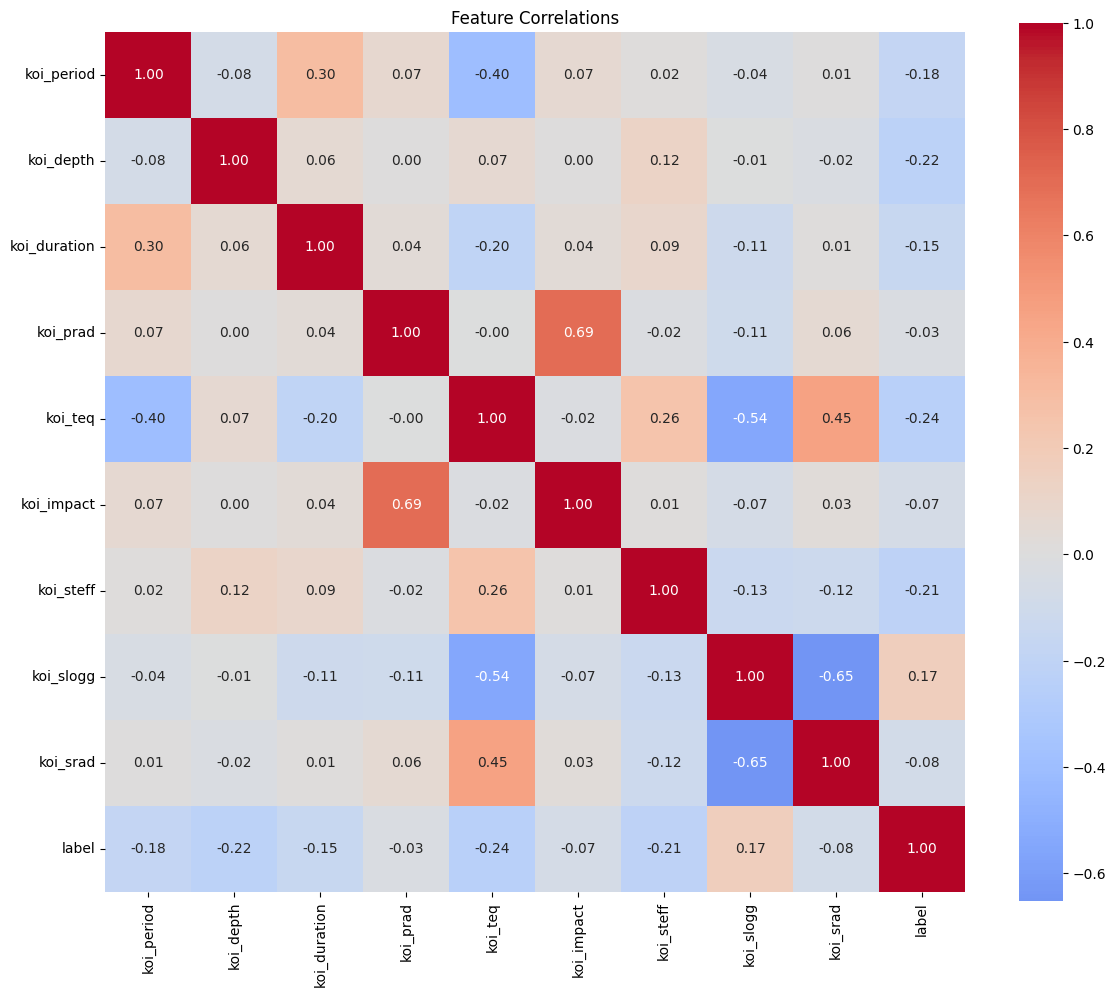

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df[key_features + ['label']].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

Here we have a correlation heatmap. Let's try to digest this. 

## What is a Correlation heatmap?
To begin with, a "feature" is another name for a measurement or a category to consider. A correlation is a measure that quantifies the strength and direction of the linear relationship between two quantitative variables within the range -1 to 1 where 0 means no pattern. When the correlation is positive (i.e measure > 0), there is a positive correlation, meaning as one feature moves in a certain direction, another moves in the same direction. When the correlation is negative (i.e measure < 0), there is a negative correlation, meaning as one feature moves in a certain direction, another moves in the opposite direction. 

A correlation matrix is just a compacted way to display all of the correlations between every feature in the form of a matrix (as the name suggests). The correlation of a feature with itself will always be +1. For example, the correlation between `koi_depth` and `koi_depth` will be +1, they both move together in the same direction and with the same magnitude.

A correlation heatmap takes a correlation matrix and puts it against a heatmap for visualization purposes.

What is important to look at is the `label` row and to see the correlations there. This will tell us about the correlation between each feature to a `CONFIRMED` exoplanet. Most of the correlations never go past 0.25 so the power of our model will come from combining these features. The "strongest" ones so far as as follows:
- `koi_teq`
- `koi_depth`
- `koi_steff`
- `koi_period`

Now let's look at the box plots for another perspective on this data and then examine it.

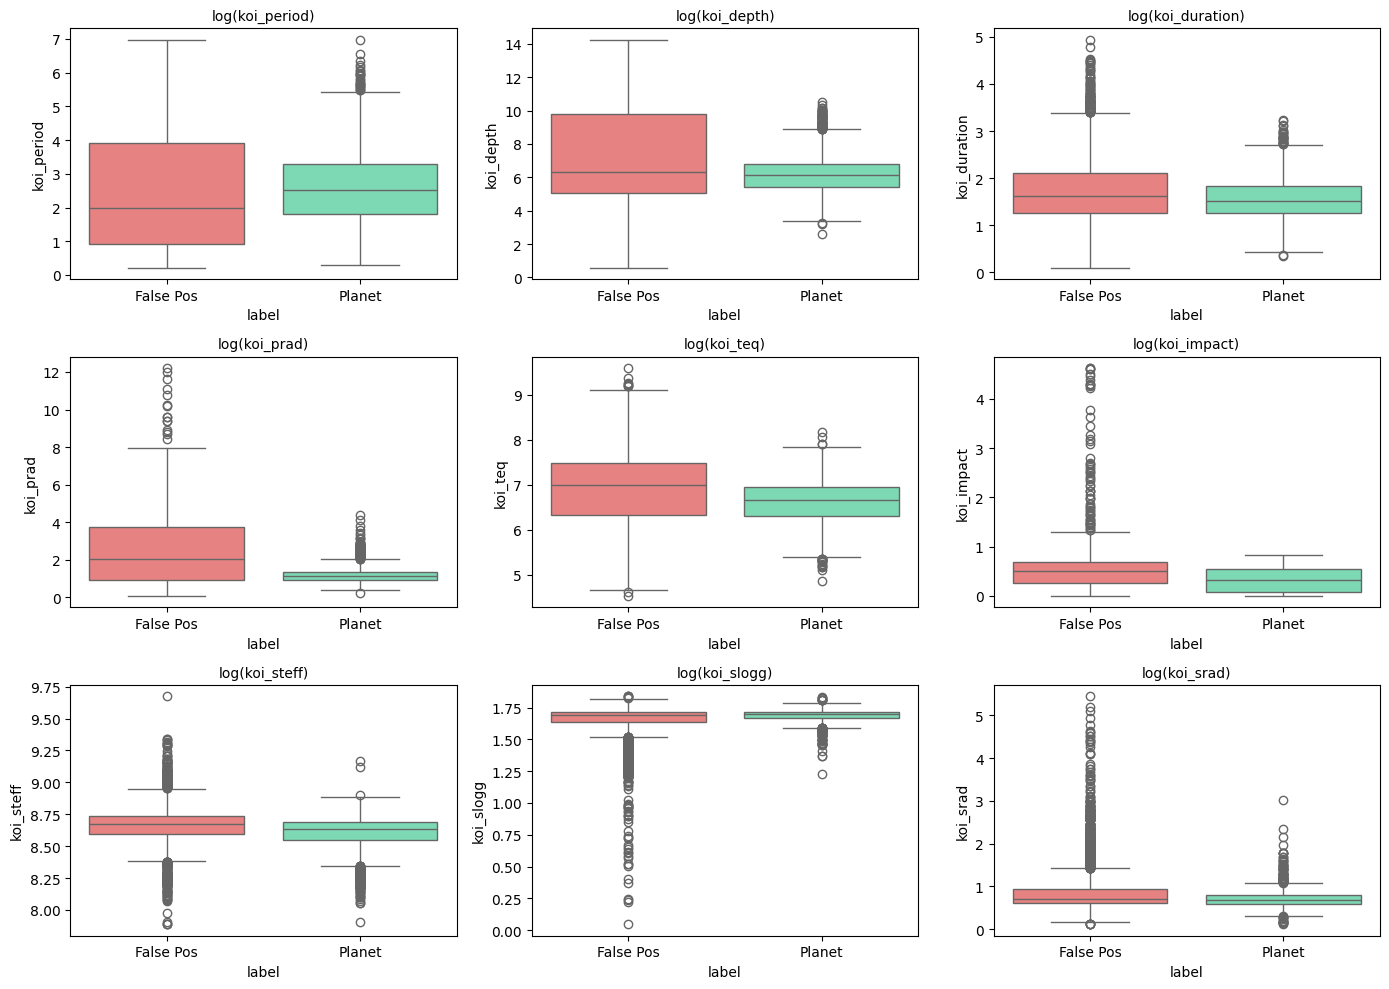

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_features):
    data = df[[col, 'label']].dropna()
    if col in log_features:
        data[col] = np.log1p(data[col])
    sns.boxplot(data=data, x='label', y=col, ax=ax,
                hue='label', palette={0: '#f87171', 1: '#6ee7b7'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False Pos', 'Planet'])
    ax.set_title(f'log({col})' if col in log_features else col, fontsize=10)
plt.tight_layout()
plt.show()

## What is a Box Plot?
The box plot is another visualization tool used in statistics:
- Minimum: The bottom line
- Maximum: The top line

Each box or rectangle shown is a quarter of the data where the lines represent 25%, 50% and 75% starting from bottom to top. 
Notice how there are dots outside the bounds of the maximum and minimum? Those are the outliers in the dataset.

The use of a box plot graph comes once we start comparing them with other box plots. Looking at this, we can notice how in `log(koi_depth)`, the false positives have a much higher 75% compared to the confirmed exoplanets. This is stating that false positives tend to have deeper transits than confirmed exoplanets. Another noticable box plot is the found in the feature `log(koi_prad)`. The false positives range across a larger interval than the confirmed exoplanets. Same thing with `log(koi_period)`. In the `log(koi_impact)` and `log(koi_srad)`, we can also notice how the false positives have much more outliers than the confirmed planets. 

Let's be careful however! While the box plots does help visualize the data and helps us choose which ones to consider promising for differentiating false positives to real exoplanets, the metric we want to use is the correlation matrix with respect to the label. We want the highest magnitude that correlates to a real exoplanet. Looking back on the correlation heatmap, the strongest indicators are `koi_teq`, `koi_depth`, `koi_steff`, and `koi_period` (0.24 - 0.18). 

Correlation with Label (ranked by absolute value):
- `koi_teq`: -0.240
- `koi_depth`: -0.221
- `koi_steff`: -0.211
- `koi_period`: -0.177
- `koi_slogg`: 0.168
- `koi_duration`: -0.151
- `koi_srad`: -0.080
- `koi_impact`: -0.070
- `koi_prad`: -0.025

Let's build a pair plot to consider how two features look like together

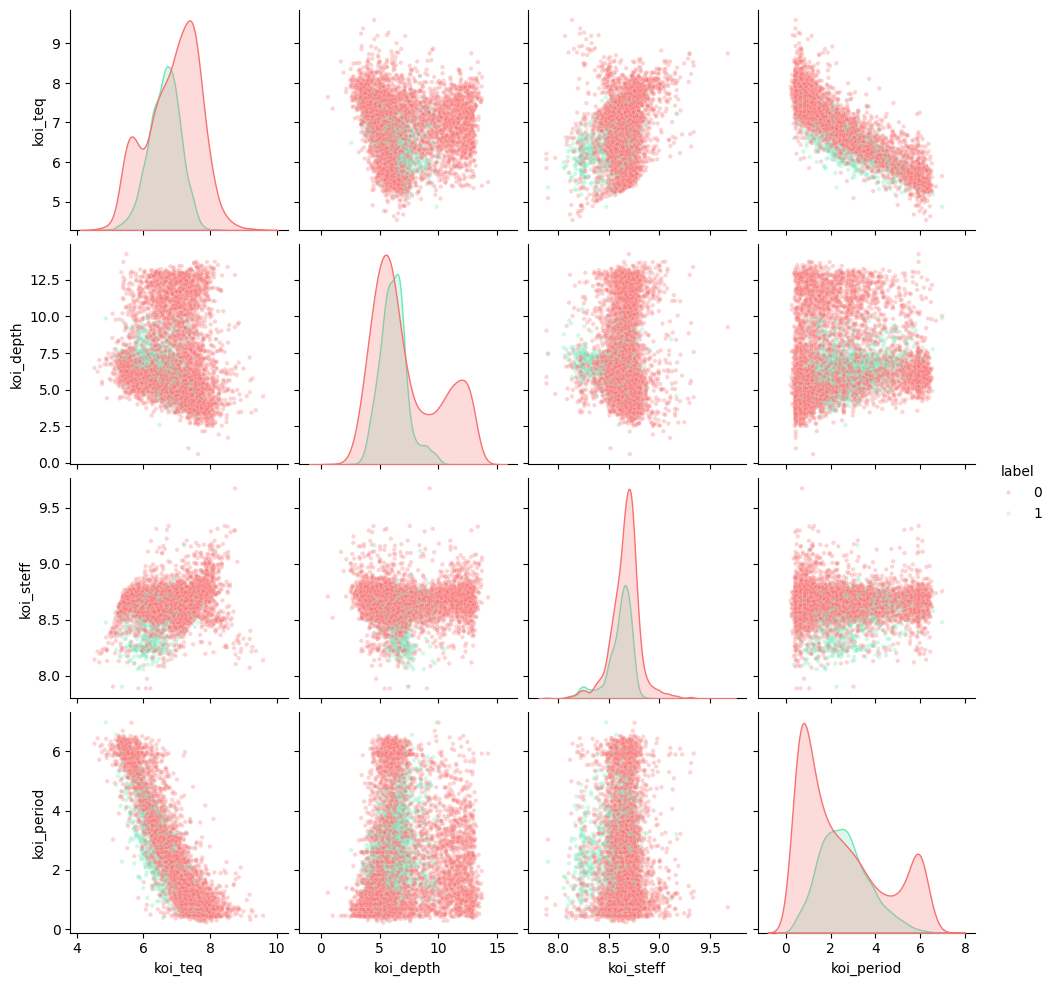

In [44]:
promising = ['koi_teq', 'koi_depth', 'koi_steff', 'koi_period']
plot_df = df[promising + ['label']].dropna()
for col in promising:
    if col in log_features:
        plot_df[col] = np.log1p(plot_df[col])
sns.pairplot(plot_df, hue='label', palette={0: '#f87171', 1: '#6ee7b7'},
             plot_kws={'alpha': 0.3, 's': 10})
plt.show()

It's a little hard to tell but we can pinpoint some key information.
- In the `koi_depth`row, confirmed exoplanets tend to cluster in a lower region (i.e shallow transit) whereas false positives tend to cluster also in a higher region (i.e deeper transit)

Though, it's kind of hard to differentiate between exoplanets and false positives in this scatter plot however. Based on the data analysis, there is no one feature that can be used as a clear indicator of a real exoplanet. This is where a machine learning model can come in to combine multiple features to detect subtleties in this dataset.